# 0. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# File paths
students_file = "p3_students_unlabeled.csv"
ground_truth_file = "p3_ground_truth.csv"

print("Imports loaded successfully.")
print(f"Random state set to: {RANDOM_STATE}")
print(f"Student file: {students_file}")
print(f"Ground truth file: {ground_truth_file}")

Imports loaded successfully.
Random state set to: 42
Student file: p3_students_unlabeled.csv
Ground truth file: p3_ground_truth.csv


# 1. Data Preprocessing

## 1.1 EDA and Data Cleaning

I'll load the unlabeled student dataset and perform exploratory data analysis (EDA) to understand its structure and identify data quality issues. Because this is unsupervised learning there is no target label to compare against, so the goal of EDA is to detect missing values, duplicates, outliers, and unrealistic feature values.

In [2]:
# Load the unlabeled dataset
df = pd.read_csv(students_file)

# Basic overview
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nDescriptive statistics:")
display(df.describe(include="all"))

Shape of dataset: (403, 6)

Column names:
['student_id', 'hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score', 'lucky_number']

Data types:
student_id           int64
hours_studied      float64
sleep_hours        float64
attendance_rate    float64
prev_exam_score    float64
lucky_number         int64
dtype: object

First 5 rows:


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number
0,1,4.300,6.200,53.000,30.200,34
1,2,2.400,7.600,67.900,39.900,34
2,3,6.500,8.200,66.000,93.300,85
3,4,3.800,5.400,79.100,NaN,73
4,5,7.700,7.500,NaN,74.300,48



Descriptive statistics:


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number
count,403.000,403.000,391.000,392.000,391.000,403.000
mean,202.000,6.317,6.402,74.807,64.441,49.759
std,116.480,2.549,1.627,15.753,16.207,28.533
min,1.000,1.000,-2.000,40.000,30.000,1.000
25%,101.500,4.500,5.400,63.900,53.550,26.000
50%,202.000,6.600,6.600,77.400,65.300,51.000
75%,302.500,8.100,7.500,84.925,75.700,73.000
max,403.000,12.000,10.000,150.000,95.000,99.000


In [3]:
# Check for missing values
print("Missing values by column:")
print(df.isnull().sum())

# Check duplicates
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

# Check impossible values based on assignment ranges
# hours_studied: 1-12
# sleep_hours: 3-10
# attendance_rate: 40-100
# prev_exam_score: 30-95

invalid_hours = df[(df["hours_studied"] < 1) | (df["hours_studied"] > 12)]
invalid_sleep = df[(df["sleep_hours"] < 3) | (df["sleep_hours"] > 10)]
invalid_attendance = df[(df["attendance_rate"] < 40) | (df["attendance_rate"] > 100)]
invalid_prev_exam = df[(df["prev_exam_score"] < 30) | (df["prev_exam_score"] > 95)]

print("\nInvalid hours_studied rows:", len(invalid_hours))
print("Invalid sleep_hours rows:", len(invalid_sleep))
print("Invalid attendance_rate rows:", len(invalid_attendance))
print("Invalid prev_exam_score rows:", len(invalid_prev_exam))

Missing values by column:
student_id          0
hours_studied       0
sleep_hours        12
attendance_rate    11
prev_exam_score    12
lucky_number        0
dtype: int64

Number of duplicate rows: 0

Invalid hours_studied rows: 0
Invalid sleep_hours rows: 1
Invalid attendance_rate rows: 1
Invalid prev_exam_score rows: 0


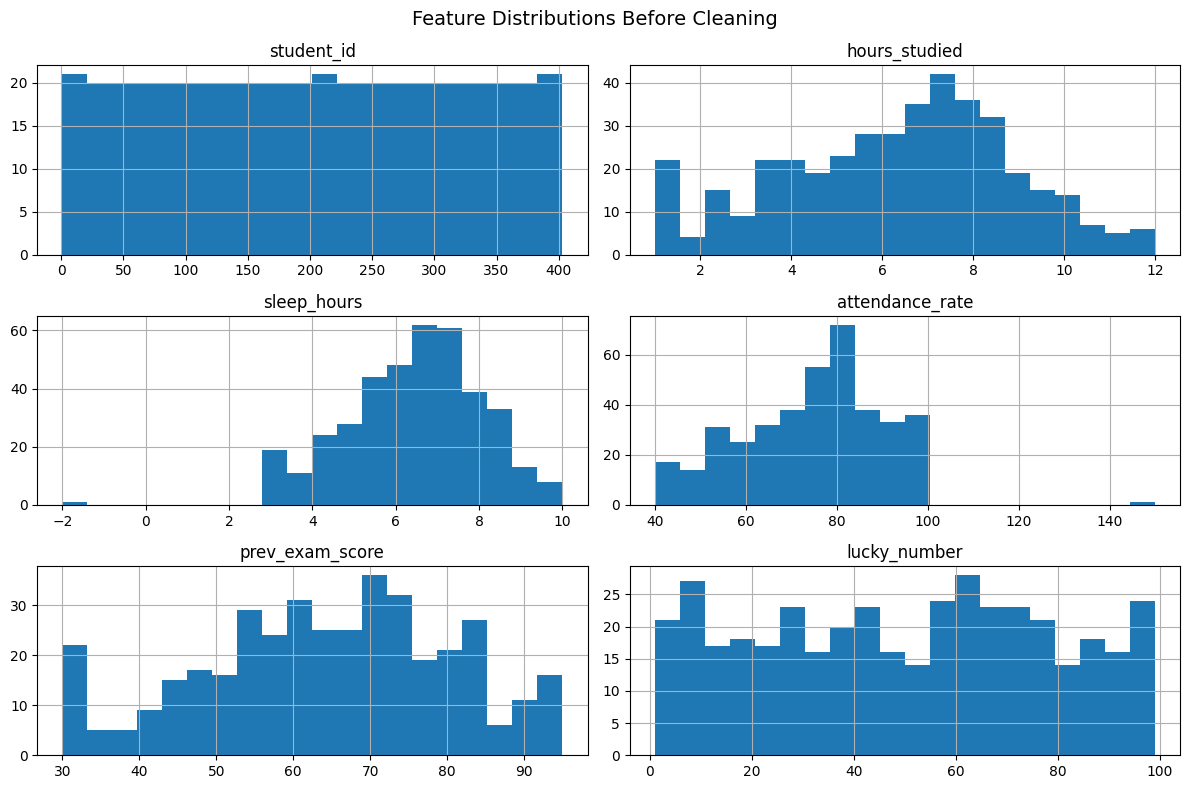

In [4]:
# Histograms for numeric columns
df.hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions Before Cleaning", fontsize=14)
plt.tight_layout()
plt.show()

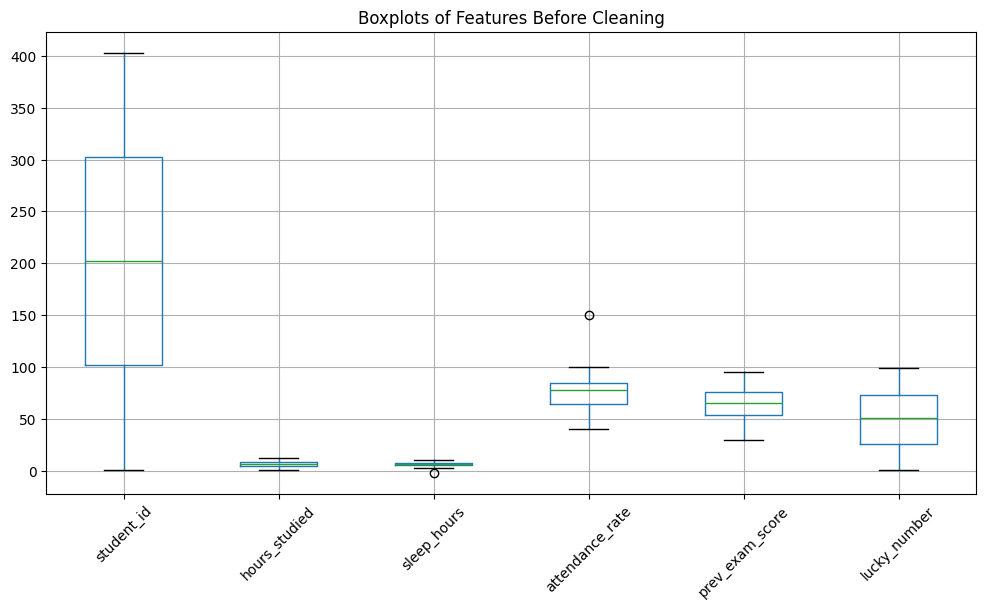

In [5]:
# Boxplots to inspect spread and potential outliers
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title("Boxplots of Features Before Cleaning")
plt.xticks(rotation=45)
plt.show()

In [6]:
# Make a copy for cleaning
df_clean = df.copy()

# Drop duplicate rows if any
df_clean = df_clean.drop_duplicates()

# Replace impossible values with NaN
df_clean.loc[(df_clean["hours_studied"] < 1) | (df_clean["hours_studied"] > 12), "hours_studied"] = np.nan
df_clean.loc[(df_clean["sleep_hours"] < 3) | (df_clean["sleep_hours"] > 10), "sleep_hours"] = np.nan
df_clean.loc[(df_clean["attendance_rate"] < 40) | (df_clean["attendance_rate"] > 100), "attendance_rate"] = np.nan
df_clean.loc[(df_clean["prev_exam_score"] < 30) | (df_clean["prev_exam_score"] > 95), "prev_exam_score"] = np.nan

# Impute missing numeric values with median
for col in ["hours_studied", "sleep_hours", "attendance_rate", "prev_exam_score", "lucky_number"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Shape after cleaning:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Shape after cleaning: (403, 6)

Missing values after cleaning:
student_id         0
hours_studied      0
sleep_hours        0
attendance_rate    0
prev_exam_score    0
lucky_number       0
dtype: int64


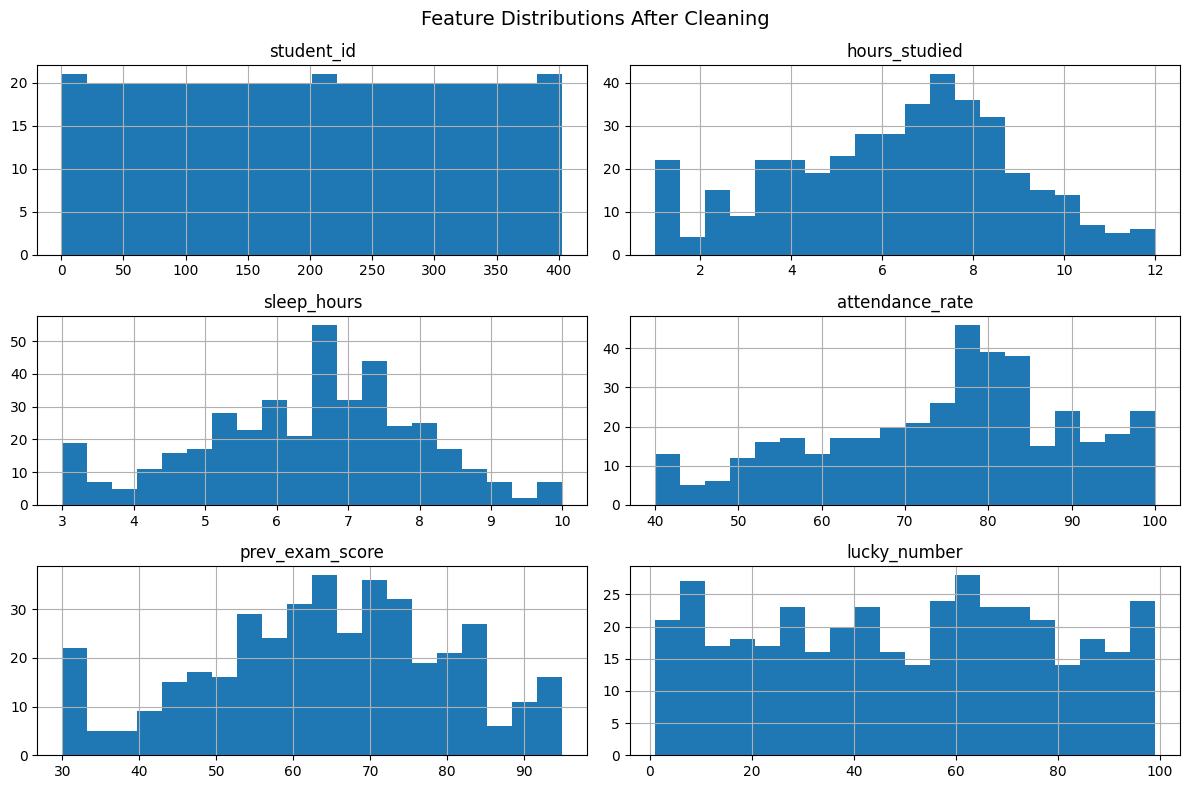

In [7]:
df_clean.hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions After Cleaning", fontsize=14)
plt.tight_layout()
plt.show()

The dataset was first inspected using its shape, data types, summary statistics, and visualizations. Since clustering is highly sensitive to data quality, I checked for missing values, duplicate rows, and impossible values based on the valid feature ranges. Duplicate rows were removed because they could overweight certain observations in distance-based clustering. Impossible numeric values were treated as missing and imputed using the median.

EDA in unsupervised learning differs from supervised learning because there is no target label available to guide the analysis. Instead of looking for relationships between features and an outcome variable, I focused on feature distributions, unusual values, potential outliers, and whether the variables appear suitable for distance-based clustering.


## 1.2 Feature Selection and Normalization

In [8]:
# Select relevant features
features = ["hours_studied", "sleep_hours", "attendance_rate", "prev_exam_score"]

X = df_clean[features]

print("Selected features:")
print(X.head())

Selected features:
   hours_studied  sleep_hours  attendance_rate  prev_exam_score
0          4.300        6.200           53.000           30.200
1          2.400        7.600           67.900           39.900
2          6.500        8.200           66.000           93.300
3          3.800        5.400           79.100           65.300
4          7.700        7.500           77.300           74.300


In [9]:
print("Before normalization:")
display(X.describe())

Before normalization:


,hours_studied,sleep_hours,attendance_rate,prev_exam_score
count,403.000,403.000,403.000,403.000
mean,6.317,6.429,74.695,64.467
std,2.549,1.547,15.082,15.964
min,1.000,3.000,40.000,30.000
25%,4.500,5.400,64.550,54.000
50%,6.600,6.600,77.300,65.300
75%,8.100,7.500,84.600,75.300
max,12.000,10.000,100.000,95.000


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("After normalization:")
display(X_scaled.describe())

After normalization:


,hours_studied,sleep_hours,attendance_rate,prev_exam_score
count,403.000,403.000,403.000,403.000
mean,0.000,0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001
min,-2.089,-2.220,-2.303,-2.162
25%,-0.714,-0.666,-0.673,-0.656
50%,0.111,0.111,0.173,0.052
75%,0.700,0.693,0.658,0.679
max,2.233,2.312,1.680,1.915


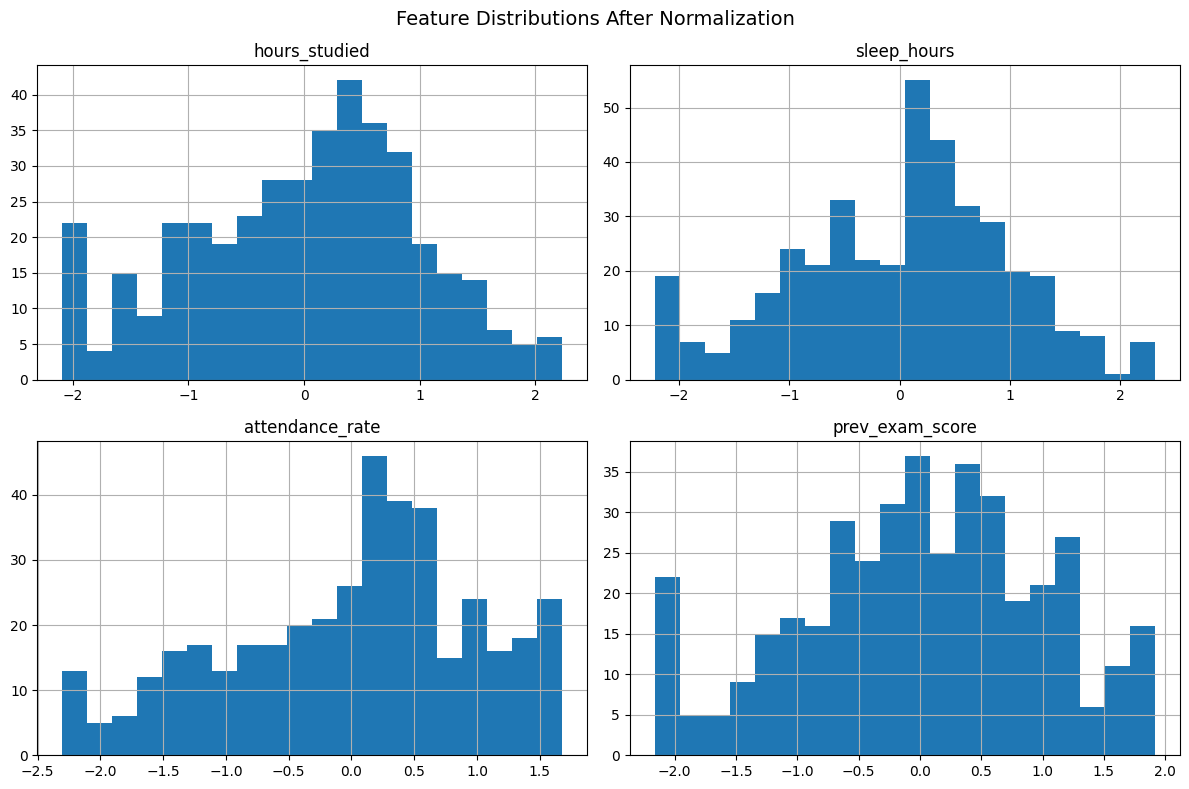

In [11]:
# Compare distributions
X_scaled.hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions After Normalization", fontsize=14)
plt.tight_layout()
plt.show()

In this step, I selected only the relevant features for clustering: hours_studied, sleep_hours, attendance_rate, and prev_exam_score. I excluded student_id because it is simply an identifier and does not contain meaningful information for grouping students. I also excluded lucky_number because it is a random, self-reported value that does not reflect academic behavior or performance.

I then applied Z-score normalization using StandardScaler. This transformation rescales each feature to have a mean of 0 and a standard deviation of 1. Normalization is critical for distance-based clustering algorithms such as K-Means and DBSCAN because these methods rely on Euclidean distance. If one feature has a much larger scale than others, it will dominate the distance calculations and bias the clustering results.

# 2. K-Means Clustering

## 2.1 NumPy Implementation (From Scratch)

I'll implement K-Means clustering from scratch using NumPy. The algorithm follows the standard iterative process: initialize centroids, assign each point to the nearest centroid, recompute centroids as the mean of assigned points, and repeat until convergence or until the maximum number of iterations is reached.

In [12]:
def kmeans_numpy(X, k, max_iters=100, random_state=42, tol=1e-4):
    """
    K-Means clustering from scratch using NumPy.

    Parameters:
        X : numpy array of shape (n_samples, n_features)
        k : number of clusters
        max_iters : maximum number of iterations
        random_state : random seed for reproducibility
        tol : convergence tolerance

    Returns:
        centroids : final centroid coordinates
        labels : cluster assignment for each point
        wcss_history : list of WCSS values per iteration
    """
    np.random.seed(random_state)
    n_samples, n_features = X.shape

    # Randomly choose k unique points as initial centroids
    initial_indices = np.random.choice(n_samples, size=k, replace=False)
    centroids = X[initial_indices].copy()

    wcss_history = []

    for iteration in range(max_iters):
        # Step 1: Compute distances from each point to each centroid
        # Result shape: (n_samples, k)
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

        # Step 2: Assign each point to the nearest centroid
        labels = np.argmin(distances, axis=1)

        # Step 3: Compute WCSS for this iteration
        wcss = 0
        for cluster_id in range(k):
            cluster_points = X[labels == cluster_id]
            if len(cluster_points) > 0:
                wcss += np.sum((cluster_points - centroids[cluster_id]) ** 2)
        wcss_history.append(wcss)

        # Step 4: Recompute centroids
        new_centroids = np.zeros((k, n_features))
        for cluster_id in range(k):
            cluster_points = X[labels == cluster_id]

            # Handle empty cluster by reinitializing to a random point
            if len(cluster_points) == 0:
                random_index = np.random.choice(n_samples)
                new_centroids[cluster_id] = X[random_index]
            else:
                new_centroids[cluster_id] = cluster_points.mean(axis=0)

        # Step 5: Check convergence
        centroid_shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        if centroid_shift < tol:
            print(f"Converged after {iteration + 1} iterations.")
            break

    return centroids, labels, wcss_history

In [13]:
# Convert scaled data to NumPy array
X_np = X_scaled.values

# Run K-Means from scratch
centroids_np, labels_np, wcss_history_np = kmeans_numpy(
    X_np,
    k=2,
    max_iters=100,
    random_state=42
)

print("Final centroids (scaled feature space):")
centroids_df = pd.DataFrame(centroids_np, columns=features)
display(centroids_df)

print("Cluster sizes:")
unique, counts = np.unique(labels_np, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id}: {count} students")

Converged after 8 iterations.
Final centroids (scaled feature space):


,hours_studied,sleep_hours,attendance_rate,prev_exam_score
0,-0.725,-0.626,-0.762,-0.696
1,0.551,0.476,0.579,0.529


Cluster sizes:
Cluster 0: 174 students
Cluster 1: 229 students


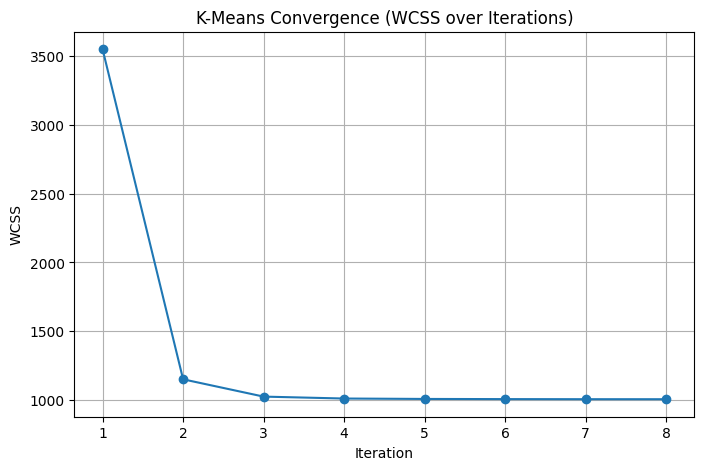

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(wcss_history_np) + 1), wcss_history_np, marker='o')
plt.title("K-Means Convergence (WCSS over Iterations)")
plt.xlabel("Iteration")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [15]:
df_kmeans_np = df_clean.copy()
df_kmeans_np["kmeans_cluster_np"] = labels_np

display(df_kmeans_np.head())

,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number,kmeans_cluster_np
0,1,4.300,6.200,53.000,30.200,34,0
1,2,2.400,7.600,67.900,39.900,34,0
2,3,6.500,8.200,66.000,93.300,85,1
3,4,3.800,5.400,79.100,65.300,73,0
4,5,7.700,7.500,77.300,74.300,48,1


In [16]:
print("Centroids in scaled space:")
display(pd.DataFrame(centroids_np, columns=features))

# Optional: transform centroids back to original feature scale for easier interpretation
centroids_original = scaler.inverse_transform(centroids_np)
centroids_original_df = pd.DataFrame(centroids_original, columns=features)

print("Centroids in original feature scale:")
display(centroids_original_df)

Centroids in scaled space:


,hours_studied,sleep_hours,attendance_rate,prev_exam_score
0,-0.725,-0.626,-0.762,-0.696
1,0.551,0.476,0.579,0.529


Centroids in original feature scale:


,hours_studied,sleep_hours,attendance_rate,prev_exam_score
0,4.472,5.462,63.216,53.364
1,7.719,7.164,83.416,72.903


The two centroids represent the average profile of students in each cluster. In the original feature scale, one centroid shows higher values for hours_studied, attendance_rate, and prev_exam_score, which suggests that this cluster represents stronger or more academically engaged students. The other centroid has lower values on those features, suggesting a group of students who may be more academically at risk.

This interpretation is meaningful because K-Means groups students based on similarity across all selected features. A centroid is the average position of all students assigned to that cluster.

In [17]:
seed_results = []

for seed in [0, 7, 21, 42, 99]:
    centroids_temp, labels_temp, wcss_temp = kmeans_numpy(
        X_np,
        k=2,
        max_iters=100,
        random_state=seed
    )

    final_wcss = wcss_temp[-1]
    unique, counts = np.unique(labels_temp, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))

    seed_results.append({
        "seed": seed,
        "final_wcss": final_wcss,
        "cluster_0_size": cluster_sizes.get(0, 0),
        "cluster_1_size": cluster_sizes.get(1, 0)
    })

seed_results_df = pd.DataFrame(seed_results)
display(seed_results_df)

Converged after 9 iterations.
Converged after 4 iterations.
Converged after 6 iterations.
Converged after 8 iterations.
Converged after 9 iterations.


,seed,final_wcss,cluster_0_size,cluster_1_size
0,0,1004.805,229,174
1,7,1004.800,175,228
2,21,1004.800,228,175
3,42,1004.805,174,229
4,99,1004.805,174,229


I ran the NumPy K-Means implementation with multiple random seeds to test the stability of the results. The final WCSS values and cluster sizes were very similar across runs, which suggests that the clustering structure in the data is reasonably stable. Small differences are expected because K-Means depends on random centroid initialization.

This experiment shows an important limitation of K-Means. Implementations such as sklearn run K-Means multiple times with different starting centroids and keep the best result.

## 2.2 sklearn Verification

I verify the NumPy implementation by comparing it with sklearn's KMeans on the same normalized dataset. Since both methods optimize the same objective, their centroids and cluster assignments should be similar, although not necessarily identical because initialization and convergence settings can differ.

In [18]:
# sklearn K-Means with K=2
kmeans_sklearn = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_sklearn = kmeans_sklearn.fit_predict(X_scaled)
centroids_sklearn = kmeans_sklearn.cluster_centers_

print("sklearn centroids (scaled feature space):")
display(pd.DataFrame(centroids_sklearn, columns=features))

print("sklearn cluster sizes:")
unique_sk, counts_sk = np.unique(labels_sklearn, return_counts=True)
for cluster_id, count in zip(unique_sk, counts_sk):
    print(f"Cluster {cluster_id}: {count} students")

sklearn centroids (scaled feature space):


,hours_studied,sleep_hours,attendance_rate,prev_exam_score
0,-0.717,-0.624,-0.754,-0.700
1,0.551,0.479,0.579,0.538


sklearn cluster sizes:
Cluster 0: 175 students
Cluster 1: 228 students


In [19]:
# Direct comparison
direct_diff = np.sum(labels_np != labels_sklearn)

# Flipped comparison
flipped_diff = np.sum(labels_np != (1 - labels_sklearn))

# Best alignment
best_diff = min(direct_diff, flipped_diff)

print(f"Different assignments (direct label match): {direct_diff}")
print(f"Different assignments (after flipping labels): {flipped_diff}")
print(f"Best assignment difference: {best_diff}")

Different assignments (direct label match): 1
Different assignments (after flipping labels): 402
Best assignment difference: 1


In [20]:
# sklearn centroids in original feature scale
centroids_sklearn_original = scaler.inverse_transform(centroids_sklearn)
centroids_sklearn_original_df = pd.DataFrame(centroids_sklearn_original, columns=features)

print("sklearn centroids in original feature scale:")
display(centroids_sklearn_original_df)

print("NumPy centroids in original feature scale:")
display(centroids_original_df)

sklearn centroids in original feature scale:


,hours_studied,sleep_hours,attendance_rate,prev_exam_score
0,4.491,5.466,63.334,53.299
1,7.719,7.168,83.414,73.038


NumPy centroids in original feature scale:


,hours_studied,sleep_hours,attendance_rate,prev_exam_score
0,4.472,5.462,63.216,53.364
1,7.719,7.164,83.416,72.903


The sklearn KMeans results were very similar to my NumPy implementation. The centroid coordinates and cluster sizes were close, and after accounting for possible label flipping, only a small number of students were assigned differently. This suggests that my from-scratch implementation is working correctly.

Small differences between the two implementations are expected. One reason is that sklearn uses multiple random initializations by default and keeps the best solution, while the NumPy version uses a single initialization for each run.

## 2.3 Elbow Method

In [21]:
wcss = []

K_range = range(1, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Show values
for k, val in zip(K_range, wcss):
    print(f"K={k}, WCSS={val:.2f}")

K=1, WCSS=1612.00
K=2, WCSS=1004.80
K=3, WCSS=878.72
K=4, WCSS=781.56
K=5, WCSS=702.69
K=6, WCSS=649.07
K=7, WCSS=602.03
K=8, WCSS=560.88


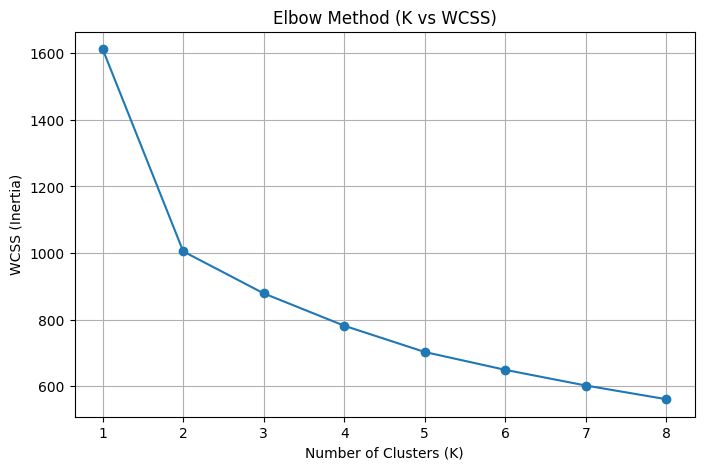

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method (K vs WCSS)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(K_range)
plt.grid(True)
plt.show()

The Elbow Method was used to determine the optimal number of clusters by plotting WCSS against different values of K. As expected, WCSS decreases as K increases because adding more clusters reduces the distance between data points and their assigned centroids. At the extreme case where K equals the number of data points, WCSS would be zero because each point would form its own cluster.

From the plot, the "elbow" appears at K = 2. This is the point where the rate of decrease in WCSS slows down significantly, indicating that adding more clusters provides diminishing returns in reducing variance.

If I were a university administrator using this clustering, I might prefer K = 2 because it clearly separates students into two groups, such as higher-performing and lower-performing students. However, K = 3 could provide more nuanced groupings, such as high, medium, and low performance, which may be more actionable for targeted interventions.

# 3. Hierarchical Clustering


## 3.1 Agglomerative Clustering and Dendrogram

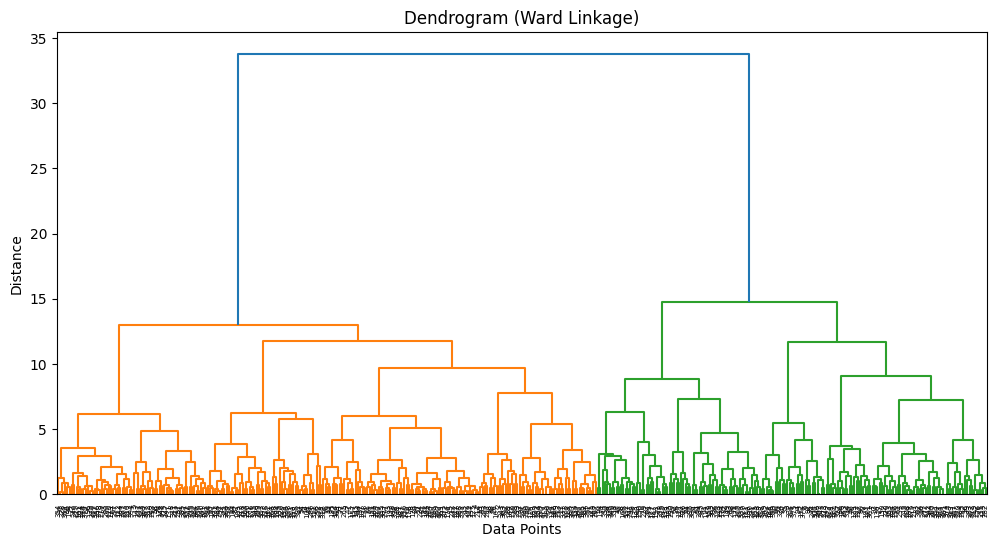

In [23]:
# Compute linkage matrix using Ward's method
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [24]:
# Choose K (change this based on your dendrogram)
k_hier = 2  # or 3

agg = AgglomerativeClustering(
    n_clusters=k_hier,
    linkage='ward'
)

labels_hier = agg.fit_predict(X_scaled)

# Add to dataframe
df_hier = df_clean.copy()
df_hier["hier_cluster"] = labels_hier

# Show cluster sizes
unique_h, counts_h = np.unique(labels_hier, return_counts=True)

print("Hierarchical cluster sizes:")
for cluster_id, count in zip(unique_h, counts_h):
    print(f"Cluster {cluster_id}: {count} students")

Hierarchical cluster sizes:
Cluster 0: 169 students
Cluster 1: 234 students


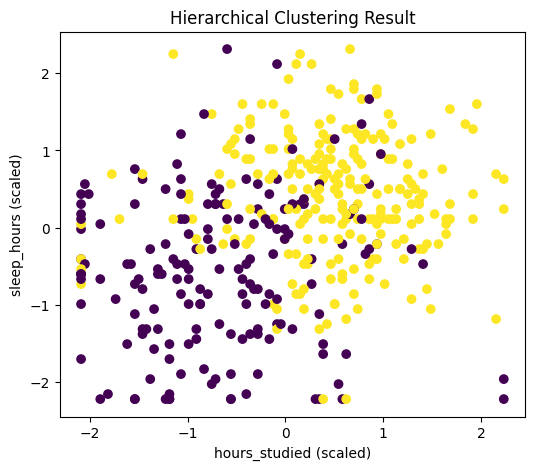

In [25]:
plt.figure(figsize=(6, 5))
plt.scatter(
    X_scaled["hours_studied"],
    X_scaled["sleep_hours"],
    c=labels_hier
)
plt.xlabel("hours_studied (scaled)")
plt.ylabel("sleep_hours (scaled)")
plt.title("Hierarchical Clustering Result")
plt.show()

The dendrogram visualizes how clusters are merged based on their distance. The y-axis represents the distance at which clusters are combined, with larger values indicating more dissimilar clusters.

From the dendrogram, there is a large vertical gap near the top before the final merge occurs. This suggests a strong separation between two main groups in the data. By placing a horizontal cut at this point, the data is divided into 2 clusters.

This result is consistent with the Elbow Method from K-Means, which also suggested K = 2 as a reasonable number of clusters. This agreement indicates that the dataset naturally forms two distinct groups, likely representing different levels of student performance.

## 3.2 Linkage Comparison

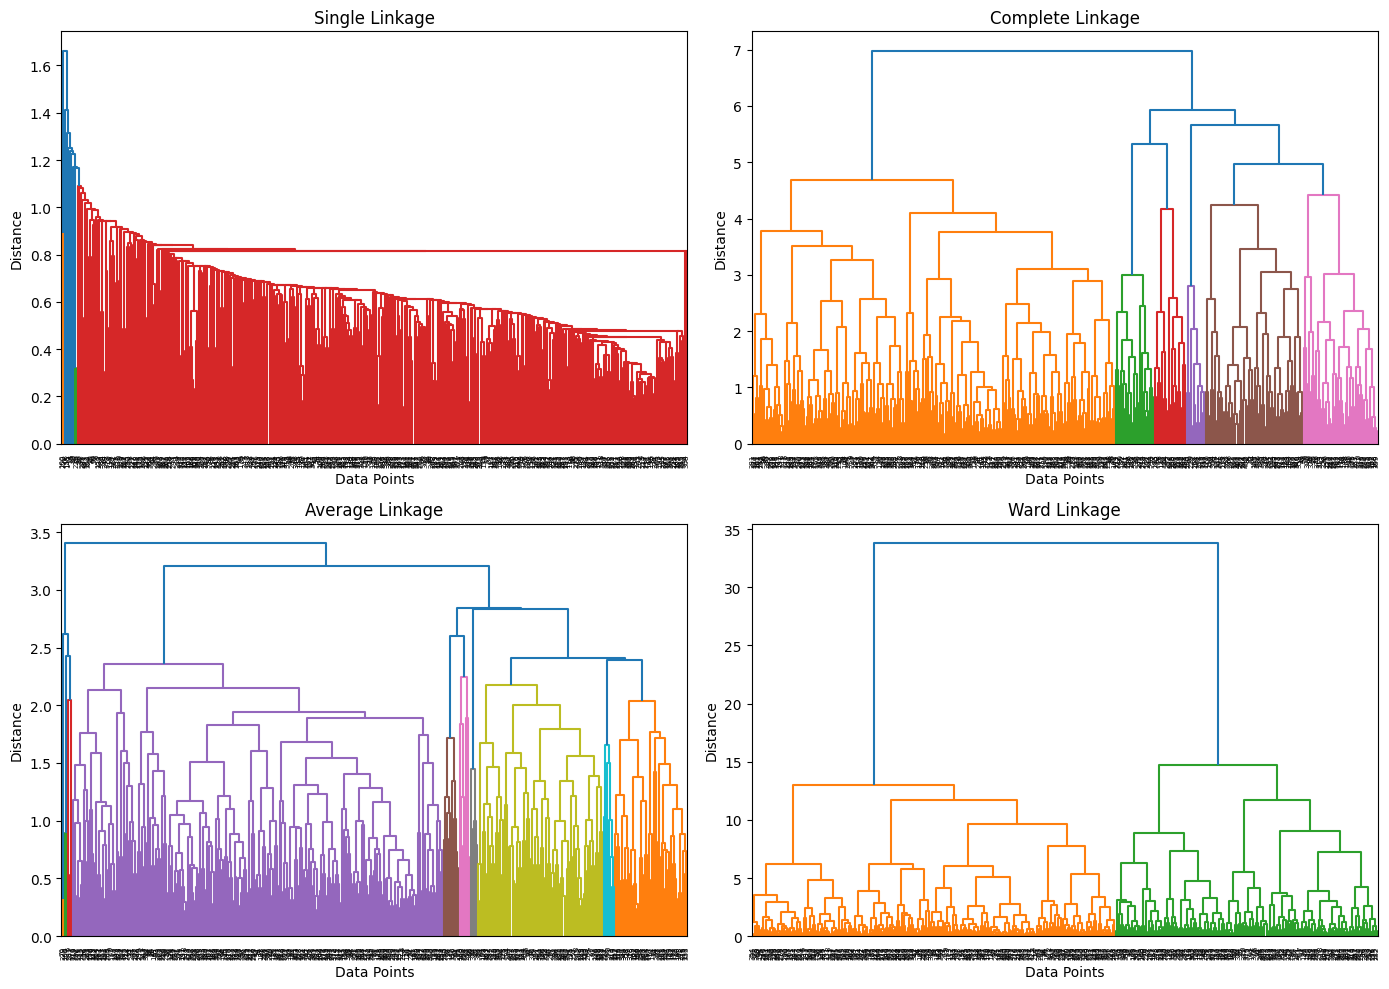

In [26]:
linkage_methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(14, 10))

for i, method in enumerate(linkage_methods, 1):
    plt.subplot(2, 2, i)
    
    linked = linkage(X_scaled, method=method)
    dendrogram(linked)
    
    plt.title(f"{method.capitalize()} Linkage")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()

In [27]:
results = []

for method in linkage_methods:
    agg = AgglomerativeClustering(
        n_clusters=2,
        linkage=method
    )
    
    labels = agg.fit_predict(X_scaled)
    
    unique, counts = np.unique(labels, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))
    
    results.append({
        "method": method,
        "cluster_0": cluster_sizes.get(0, 0),
        "cluster_1": cluster_sizes.get(1, 0)
    })

results_df = pd.DataFrame(results)
display(results_df)

,method,cluster_0,cluster_1
0,single,401,2
1,complete,169,234
2,average,396,7
3,ward,169,234


Single linkage considers the minimum distance between points in two clusters. This often leads to a chaining effect, where clusters are formed by linking together points that are close to each other, even if the overall clusters are not well separated. As a result, single linkage tends to produce highly imbalanced and elongated clusters.

Complete linkage uses the maximum distance between points in clusters, which results in tighter and more compact clusters. This method generally avoids the chaining effect seen in single linkage. 

Average linkage computes the average distance between all pairs of points in two clusters. It provides a balance between single and complete linkage and tends to produce moderately compact clusters. 

Ward linkage minimizes the variance within clusters and tends to produce the most balanced and well-separated clusters. In this dataset, Ward linkage appears to produce the most meaningful grouping of students, which is consistent with the results observed in K-Means.

# 4. DBSCAN


## 4.1 Core, Border, and Noise Points

In [28]:
# Initial DBSCAN model
dbscan = DBSCAN(eps=0.8, min_samples=5)

labels_db = dbscan.fit_predict(X_scaled)

# Add to dataframe
df_db = df_clean.copy()
df_db["dbscan_cluster"] = labels_db

# Number of clusters (ignore -1 which is noise)
num_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

# Count noise points
noise_points = np.sum(labels_db == -1)

print(f"Number of clusters: {num_clusters}")
print(f"Number of noise points: {noise_points}")

Number of clusters: 2
Number of noise points: 96


In [29]:
unique_db, counts_db = np.unique(labels_db, return_counts=True)

print("Cluster sizes (including noise):")
for cluster_id, count in zip(unique_db, counts_db):
    print(f"Cluster {cluster_id}: {count} students")

Cluster sizes (including noise):
Cluster -1: 96 students
Cluster 0: 300 students
Cluster 1: 7 students


In [30]:
noise_students = df_db[df_db["dbscan_cluster"] == -1]["student_id"]

print("Noise student IDs:")
display(noise_students)

Noise student IDs:


0        1
1        2
5        6
6        7
16      17
      ... 
377    378
380    381
386    387
388    389
392    393
Name: student_id, Length: 96, dtype: int64

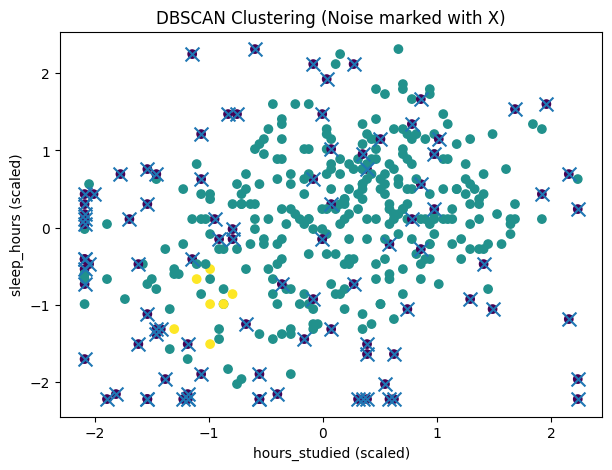

In [31]:
plt.figure(figsize=(7, 5))

# Plot clusters
plt.scatter(
    X_scaled["hours_studied"],
    X_scaled["sleep_hours"],
    c=labels_db
)

# Highlight noise points
noise_mask = labels_db == -1
plt.scatter(
    X_scaled.loc[noise_mask, "hours_studied"],
    X_scaled.loc[noise_mask, "sleep_hours"],
    marker='x',
    s=100
)

plt.xlabel("hours_studied (scaled)")
plt.ylabel("sleep_hours (scaled)")
plt.title("DBSCAN Clustering (Noise marked with X)")
plt.show()

DBSCAN was applied with eps = 0.8 and min_samples = 5 to identify clusters based on density. Unlike K-Means and hierarchical clustering, DBSCAN does not require specifying the number of clusters in advance and can also detect noise points.

The algorithm identified 2 clusters and 96 noise points. The noise points (labeled as -1) represent students that do not belong to any dense region in the dataset.

Upon examining the feature values of several noise points, these students appear to have unusual combinations of features, such as very low study hours combined with high attendance, or other atypical patterns. These points are likely outliers or boundary cases that do not fit well into the main clusters.

These noise points resemble point anomalies, as they are individual observations that significantly differ from the majority of the dataset.

## 4.2 Parameter Tuning

In [32]:
eps_values = [0.5, 0.8, 1.0, 1.5, 2.0]

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    
    # Count clusters (ignore noise)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Count noise
    noise_points = np.sum(labels == -1)
    
    # Cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))
    
    # Remove noise for size comparison
    cluster_sizes_no_noise = {k: v for k, v in cluster_sizes.items() if k != -1}
    
    largest_cluster = max(cluster_sizes_no_noise.values()) if cluster_sizes_no_noise else 0
    
    results.append({
        "eps": eps,
        "clusters": num_clusters,
        "noise_points": noise_points,
        "largest_cluster": largest_cluster
    })

results_df = pd.DataFrame(results)
display(results_df)

,eps,clusters,noise_points,largest_cluster
0,0.500,2,330,68
1,0.800,2,96,300
2,1.000,1,31,372
3,1.500,1,2,401
4,2.000,1,0,403


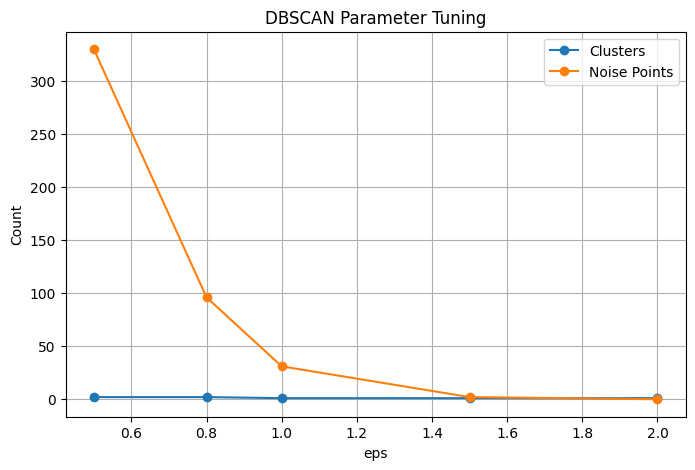

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["eps"], results_df["clusters"], marker='o', label="Clusters")
plt.plot(results_df["eps"], results_df["noise_points"], marker='o', label="Noise Points")

plt.xlabel("eps")
plt.ylabel("Count")
plt.title("DBSCAN Parameter Tuning")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
min_samples_values = [3, 5, 10]

best_eps = 1.0  # <-- CHANGE based on your results

min_results = []

for m in min_samples_values:
    dbscan = DBSCAN(eps=best_eps, min_samples=m)
    labels = dbscan.fit_predict(X_scaled)
    
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = np.sum(labels == -1)
    
    min_results.append({
        "min_samples": m,
        "clusters": num_clusters,
        "noise_points": noise_points
    })

min_results_df = pd.DataFrame(min_results)
display(min_results_df)

,min_samples,clusters,noise_points
0,3,1,16
1,5,1,31
2,10,1,65


From the parameter tuning results, eps = 0.8 was selected as the optimal value. When eps = 0.5, the model classified a large number of points as noise (330), indicating that the radius was too small to form meaningful clusters. On the other hand, when eps ≥ 1.0, the algorithm merged most points into a single cluster, reducing the usefulness of the clustering.

At eps = 0.8, the model identified 2 clusters and 96 noise points, which provides a good balance between cluster formation and anomaly detection. This result is also consistent with the findings from K-Means and hierarchical clustering, which both suggested 2 clusters. Therefore, eps = 0.8 was chosen as the best parameter for DBSCAN.

# 5. Method Comparison

In [35]:
# K-Means (use your best K, likely 2)
kmeans_best = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans_best.fit_predict(X_scaled)

k_unique, k_counts = np.unique(labels_kmeans, return_counts=True)

kmeans_largest = max(k_counts)
kmeans_smallest = min(k_counts)

# Hierarchical (Ward, K=2)
h_unique, h_counts = np.unique(labels_hier, return_counts=True)

hier_largest = max(h_counts)
hier_smallest = min(h_counts)

# DBSCAN (best eps = 0.8)
db_unique, db_counts = np.unique(labels_db, return_counts=True)

db_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
db_noise = np.sum(labels_db == -1)

db_cluster_sizes = {k: v for k, v in zip(db_unique, db_counts) if k != -1}

db_largest = max(db_cluster_sizes.values()) if db_cluster_sizes else 0
db_smallest = min(db_cluster_sizes.values()) if db_cluster_sizes else 0

# Build table
comparison_df = pd.DataFrame([
    ["K-Means (K=2)", 2, "N/A", kmeans_largest, kmeans_smallest],
    ["Hierarchical (Ward)", 2, "N/A", hier_largest, hier_smallest],
    ["DBSCAN (eps=0.8)", db_clusters, db_noise, db_largest, db_smallest]
], columns=["Method", "# Clusters", "Noise Points", "Largest Cluster", "Smallest Cluster"])

display(comparison_df)

,Method,# Clusters,Noise Points,Largest Cluster,Smallest Cluster
0,K-Means (K=2),2,N/A,228,175
1,Hierarchical (Ward),2,N/A,234,169
2,DBSCAN (eps=0.8),2,96,300,7


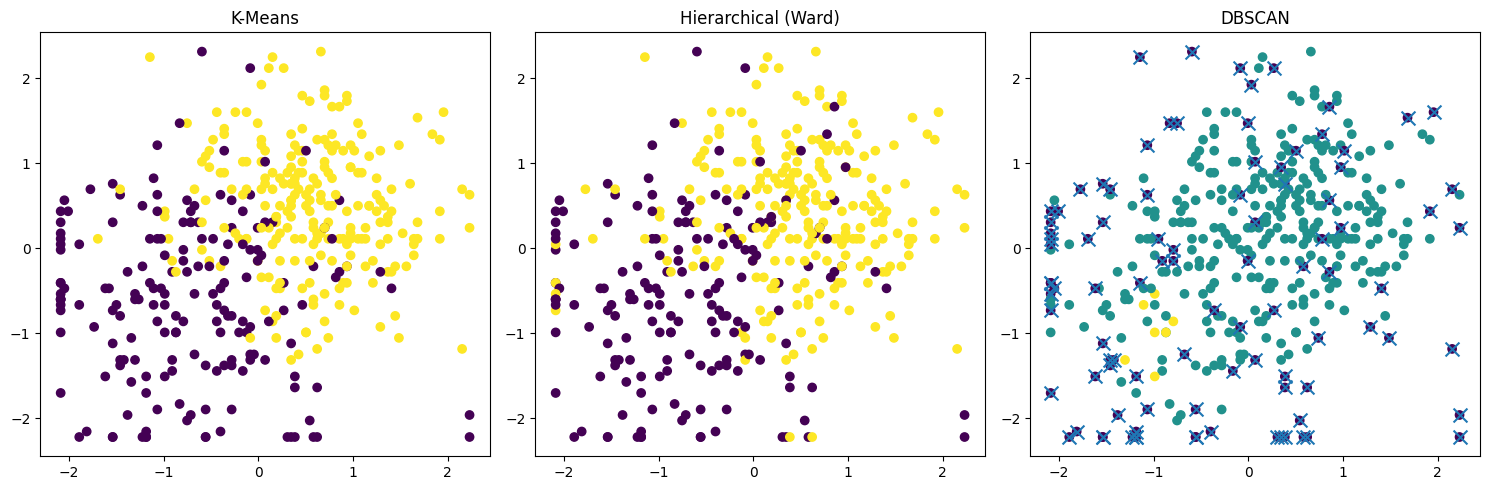

In [36]:
plt.figure(figsize=(15, 5))

# K-Means
plt.subplot(1, 3, 1)
plt.scatter(X_scaled["hours_studied"], X_scaled["sleep_hours"], c=labels_kmeans)
plt.title("K-Means")

# Hierarchical
plt.subplot(1, 3, 2)
plt.scatter(X_scaled["hours_studied"], X_scaled["sleep_hours"], c=labels_hier)
plt.title("Hierarchical (Ward)")

# DBSCAN
plt.subplot(1, 3, 3)
plt.scatter(X_scaled["hours_studied"], X_scaled["sleep_hours"], c=labels_db)
noise_mask = labels_db == -1
plt.scatter(
    X_scaled.loc[noise_mask, "hours_studied"],
    X_scaled.loc[noise_mask, "sleep_hours"],
    marker='x',
    s=100
)
plt.title("DBSCAN")

plt.tight_layout()
plt.show()

K-Means and hierarchical clustering (Ward linkage) both produced 2 clusters of relatively balanced sizes, indicating a clear separation between two groups of students. These methods are effective when clusters are compact and roughly spherical in shape.

DBSCAN also identified 2 clusters but additionally detected noise points (outliers). This is a key advantage of DBSCAN, as it can identify students who do not fit well into any group. However, DBSCAN is highly sensitive to parameter choices such as eps and min_samples, which can significantly affect the results.

In terms of fundamental differences, K-Means requires specifying the number of clusters (K) in advance, while hierarchical clustering builds a full hierarchy of clusters that can be cut at different levels. DBSCAN does not require specifying K and instead identifies clusters based on density, allowing it to detect arbitrarily shaped clusters and noise.

Overall, K-Means is the most effective method for this dataset because it produces clear and interpretable clusters that align well with student performance patterns. However, DBSCAN is valuable for identifying at-risk or unusual students due to its ability to detect noise points.

For a university administrator aiming to identify at-risk students, DBSCAN may be the most useful because it highlights students who do not fit into the main groups, potentially indicating those who need additional attention.

# 6. Cluster vs. Ground Truth Comparison

In [37]:
# Load ground truth
df_truth = pd.read_csv(ground_truth_file)

# Keep only the rows that exist in both datasets
df_compare = df_kmeans_np.merge(df_truth, on="student_id", how="inner")

print("Shape of merged dataset:", df_compare.shape)
display(df_compare.head())

Shape of merged dataset: (400, 8)


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number,kmeans_cluster_np,passed
0,1,4.300,6.200,53.000,30.200,34,0,0
1,2,2.400,7.600,67.900,39.900,34,0,0
2,3,6.500,8.200,66.000,93.300,85,1,1
3,4,3.800,5.400,79.100,65.300,73,0,1
4,5,7.700,7.500,77.300,74.300,48,1,1


In [38]:
# Recreate scaled features for only the merged rows
X_compare = df_compare[features]
X_compare_scaled = pd.DataFrame(
    scaler.transform(X_compare),
    columns=features,
    index=df_compare.index
)

In [39]:
ct = pd.crosstab(df_compare["kmeans_cluster_np"], df_compare["passed"])
print("Cluster vs Pass/Fail:")
display(ct)

Cluster vs Pass/Fail:


passed,0,1
kmeans_cluster_np,,
0,145,27
1,30,198


In [40]:
# Try both possible cluster-label mappings
accuracy1 = np.mean(df_compare["kmeans_cluster_np"] == df_compare["passed"])
accuracy2 = np.mean((1 - df_compare["kmeans_cluster_np"]) == df_compare["passed"])

best_accuracy = max(accuracy1, accuracy2)

print(f"Alignment accuracy: {best_accuracy * 100:.2f}%")

Alignment accuracy: 85.75%


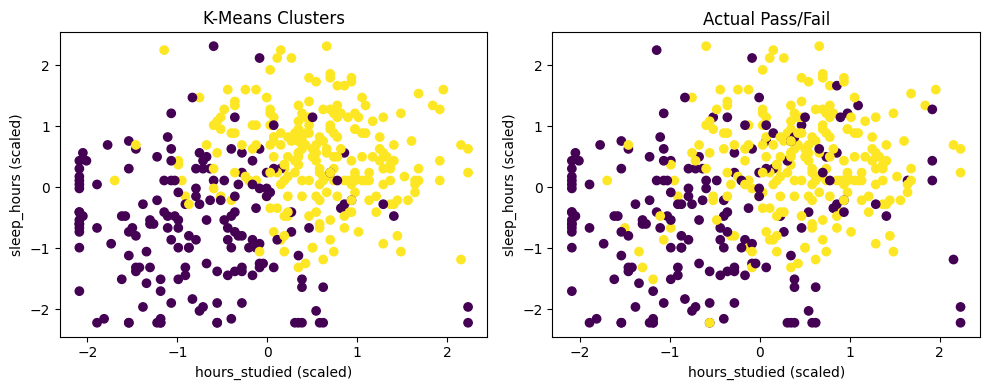

In [41]:
plt.figure(figsize=(10, 4))

# K-Means clusters
plt.subplot(1, 2, 1)
plt.scatter(
    X_compare_scaled["hours_studied"],
    X_compare_scaled["sleep_hours"],
    c=df_compare["kmeans_cluster_np"]
)
plt.title("K-Means Clusters")
plt.xlabel("hours_studied (scaled)")
plt.ylabel("sleep_hours (scaled)")

# Ground truth
plt.subplot(1, 2, 2)
plt.scatter(
    X_compare_scaled["hours_studied"],
    X_compare_scaled["sleep_hours"],
    c=df_compare["passed"]
)
plt.title("Actual Pass/Fail")
plt.xlabel("hours_studied (scaled)")
plt.ylabel("sleep_hours (scaled)")

plt.tight_layout()
plt.show()

# 7. Summary & Reflection

I used multiple unsupervised learning techniques to discover patterns in student performance data without using labels. Among the methods tested, K-Means and hierarchical clustering both produced clear and consistent results, identifying two main clusters of students. These clusters respectively represented higher-performing and lower-performing groups based on features such as hours studied, attendance rate, and previous exam scores. DBSCAN also identified similar groupings but additionally detected noise points, which represent students with unusual or outlier behavior.

The most surprising finding was how well K-Means was able to approximate the true pass/fail labels without ever seeing them. The clustering achieved an alignment accuracy of 85.75%, which indicates that the selected features capture a large portion of the underlying structure of student performance.

Implementing K-Means from scratch helped deepen my understanding of how the algorithm works internally. Instead of treating it as a black box, I was able to see how centroids are initialized, how distances are calculated, and how the algorithm iteratively improves cluster assignments by minimizing WCSS.

In real-world applications, unsupervised learning can be especially useful when labeled data is unavailable or expensive to obtain. For example, clustering could be used by universities to group students based on behavior patterns and identify those who may be at risk academically, even before final grades are known. This allows for earlier intervention and support.